In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('[FM2S]Lista_Exercícios_1.xlsx', sheet_name='06.Vendas')
df

,Dia,Loja 1,Loja 2,Loja 3,Loja 4
0,1,180,231,193,179
1,2,192,250,202,165
2,3,205,198,195,159
3,4,111,163,187,200
4,5,174,248,205,166
5,6,123,249,201,140
6,7,130,194,192,203
7,8,134,156,191,168
8,9,108,245,200,155
9,10,104,236,197,177


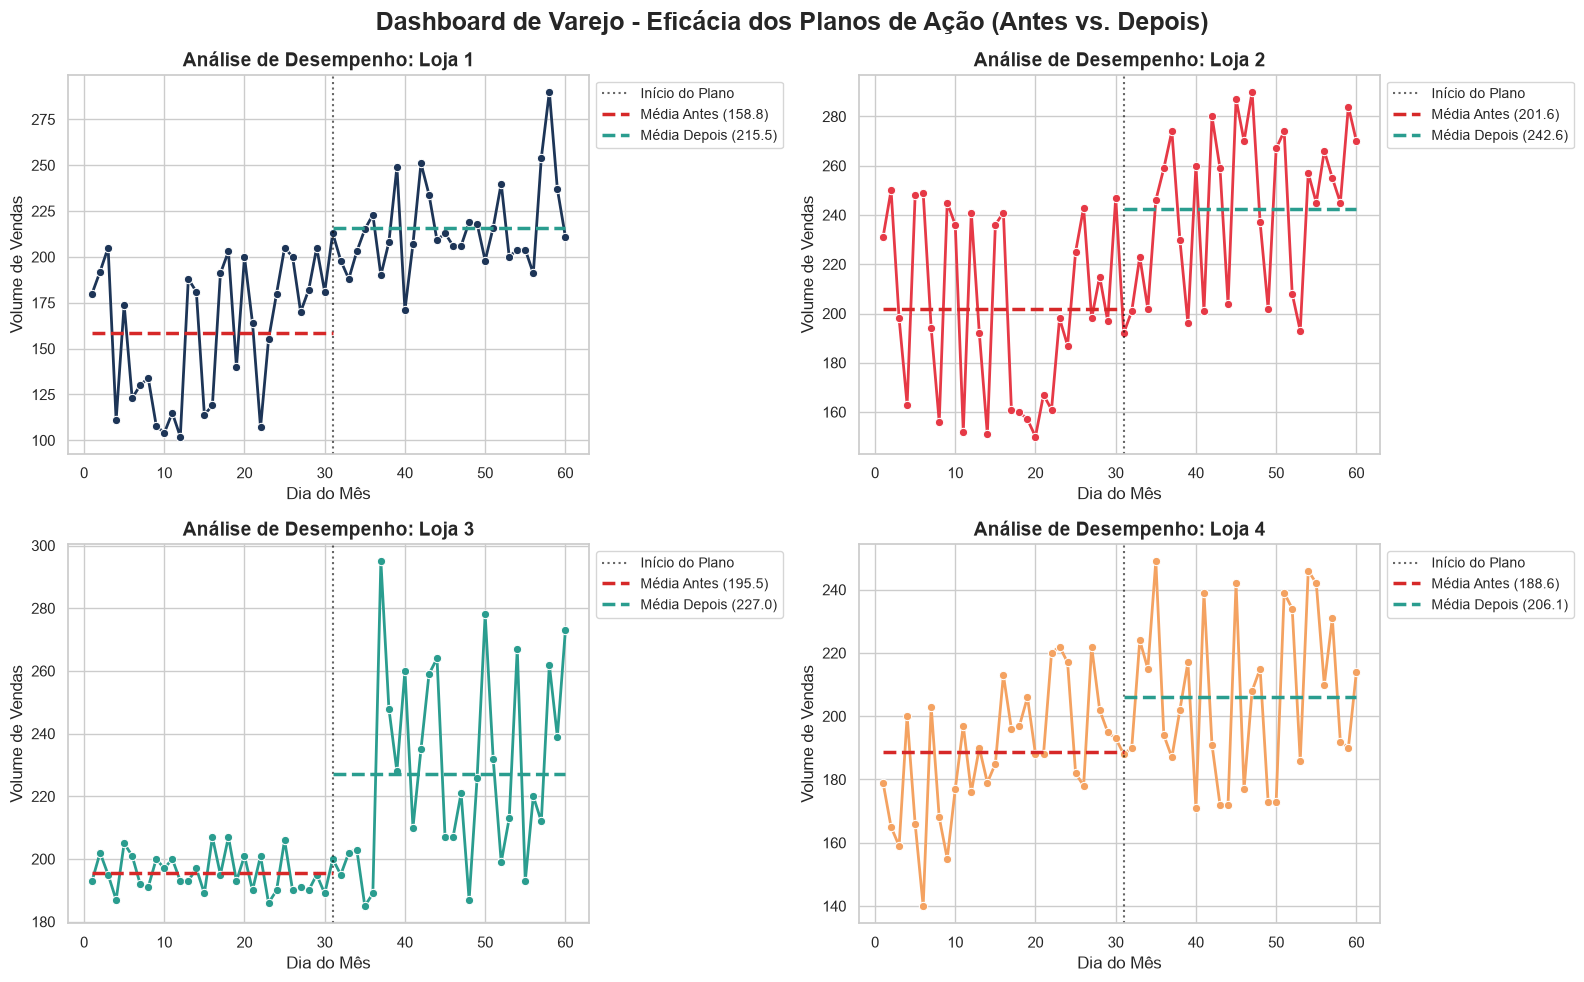

In [3]:
# Vamos dividir os dados no meio para simular o "Antes" e o "Depois" do Plano de Ação
meio = len(df) // 2
dia_corte = df['Dia'].iloc[meio]


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard de Varejo - Eficácia dos Planos de Ação (Antes vs. Depois)', fontsize=18, fontweight='bold')

lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
cores = ['#1d3557', '#e63946', '#2a9d8f', '#f4a261']
# Transforma a matriz 2x2 em uma lista simples para facilitar o laço de repetição
axes = axes.flatten()

for i, loja in enumerate(lojas):
    ax = axes[i]
    
    # Plota a linha do tempo completa de vendas
    sns.lineplot(data=df, x='Dia', y=loja, ax=ax, marker='o', color=cores[i], linewidth=2)
    
    # Calcula as médias separadas: ANTES do plano e DEPOIS do plano
    media_antes = df.iloc[:meio][loja].mean()
    media_depois = df.iloc[meio:][loja].mean()
    
    # Desenha a linha vertical de corte (O dia em que o plano de ação supostamente começou)
    ax.axvline(dia_corte, color='black', linestyle=':', alpha=0.6, label='Início do Plano')
    
    # Desenha a média ANTES do plano (Linha Vermelha)
    ax.plot([df['Dia'].min(), dia_corte], [media_antes, media_antes], 
            color='#d62828', linestyle='--', linewidth=2.5, label=f'Média Antes ({media_antes:.1f})')
    
    # Desenha a média DEPOIS do plano (Linha Verde)
    ax.plot([dia_corte, df['Dia'].max()], [media_depois, media_depois], 
            color='#2a9d8f', linestyle='--', linewidth=2.5, label=f'Média Depois ({media_depois:.1f})')
    
    # Toques finais de design
    ax.set_title(f'Análise de Desempenho: {loja}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Volume de Vendas')
    ax.set_xlabel('Dia do Mês')
    # Ajusta a legenda para não cobrir o gráfico
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()